<a href="https://colab.research.google.com/github/gorodnichenko16-cell/-/blob/main/%D0%B7%D0%B0%D0%B4%D0%B0%D0%BD%D0%B8%D0%B5_%D0%BF%D0%BE_%D1%82%D0%B5%D0%BC%D0%B5_%C2%AB%D0%AD%D0%BB%D0%B5%D0%BC%D0%B5%D0%BD%D1%82%D0%B0%D1%80%D0%BD%D1%8B%D0%B5_%D0%BC%D0%B5%D1%82%D0%BE%D0%B4%D1%8B_%D0%B0%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7%D0%B0_%D0%B2%D1%80%D0%B5%D0%BC%D0%B5%D0%BD%D0%BD%D1%8B%D1%85_%D1%80%D1%8F%D0%B4%D0%BE%D0%B2%C2%BB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Импорты и вспомогательные функции

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller

plt.rcParams["figure.figsize"] = (10, 4)

def adf_test(series, title=""):
    result = adfuller(series.dropna())
    print(f"ADF for {title}:")
    print("  ADF statistic:", result[0])
    print("  p-value      :", result[1])
    print()

def train_test_split_ts(series, test_size):
    """Простой split: обучаемся на первых (N-test_size), прогнозируем последние test_size."""
    return series.iloc[:-test_size], series.iloc[-test_size:]


 Выбор временных рядов

Возьму:

нестационарный: international-airline-passengers.csv

стационарный: ts_births_diff из задания с рождениями
Или можно взять другой стационарный, например ts_rob_diff.

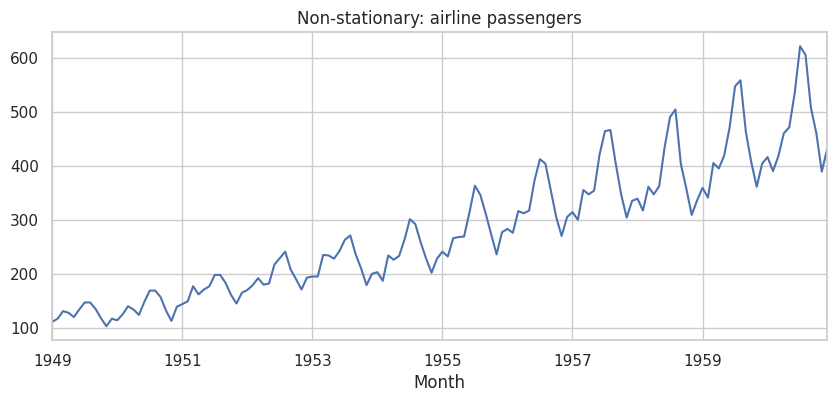

ADF for air passengers:
  ADF statistic: 0.8153688792060498
  p-value      : 0.991880243437641



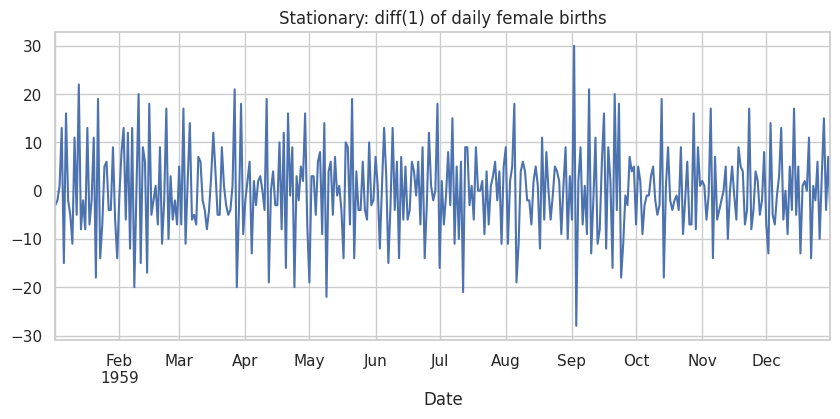

ADF for births diff(1):
  ADF statistic: -12.62517863387136
  p-value      : 1.5472400091968453e-23



In [21]:
# Нестационарный ряд
air = pd.read_csv("international-airline-passengers.csv")
air.columns = ["Month", "Passengers"]
air["Month"] = pd.to_datetime(air["Month"])
air.set_index("Month", inplace=True)
ts_nonstat = air["Passengers"]

ts_nonstat.plot(title="Non-stationary: airline passengers")
plt.show()
adf_test(ts_nonstat, "air passengers")

# Стационарный ряд (после дифференцирования рождений)
births = pd.read_csv("daily-total-female-births-in-cal.csv")
births.columns = ["Date", "Births"]
births["Date"] = pd.to_datetime(births["Date"])
births.set_index("Date", inplace=True)
ts_births = births["Births"]

ts_stat = ts_births.diff(1).dropna()

ts_stat.plot(title="Stationary: diff(1) of daily female births")
plt.show()
adf_test(ts_stat, "births diff(1)")


 Реализация MA / EMA / DEMA / TEMA

In [22]:
def ma(series, window):
    return series.rolling(window=window).mean()

def ema(series, span):
    return series.ewm(span=span, adjust=False).mean()

def dema(series, span):
    ema1 = ema(series, span)
    ema2 = ema(ema1, span)
    return 2 * ema1 - ema2

def tema(series, span):
    ema1 = ema(series, span)
    ema2 = ema(ema1, span)
    ema3 = ema(ema2, span)
    return 3 * ema1 - 3 * ema2 + ema3


 Метрики качества

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def evaluate_forecast(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
    }


Функция подбора лучшего окна для одной модели

In [30]:
def tune_and_evaluate_simple(series, model_name, param_grid, test_size=12):
    train, test = train_test_split_ts(series, test_size=test_size)
    results = []

    for p in param_grid:
        if model_name == "MA":
            fitted = ma(series, window=p)
        elif model_name == "EMA":
            fitted = ema(series, span=p)
        elif model_name == "DEMA":
            fitted = dema(series, span=p)
        elif model_name == "TEMA":
            fitted = tema(series, span=p)
        else:
            continue

        # Берём прогноз только на тестовом хвосте
        forecast = fitted.iloc[-test_size:]

        # Из-за окна первые p-1 значений fitted будут NaN, поэтому
        # просто проверяем, что на хвосте нет NaN
        if forecast.isna().any():
            continue

        metrics = evaluate_forecast(test, forecast)
        results.append((p, metrics["RMSE"]))

    if not results:
        return None, None

    best_param, best_rmse = min(results, key=lambda x: x[1])
    return best_param, best_rmse




Эксперименты для нестационарного ряда

Non-stationary | MA: best_param=2, best_RMSE=26.57575649597455
Non-stationary | EMA: best_param=2, best_RMSE=20.64762333863828
Non-stationary | DEMA: best_param=2, best_RMSE=6.710670973595339
Non-stationary | TEMA: best_param=2, best_RMSE=2.5817638181495726
Valid models for non-stationary series: {'MA': (2, np.float64(26.57575649597455)), 'EMA': (2, np.float64(20.64762333863828)), 'DEMA': (2, np.float64(6.710670973595339)), 'TEMA': (2, np.float64(2.5817638181495726))}
Best model for non-stationary series: ('TEMA', (2, np.float64(2.5817638181495726)))


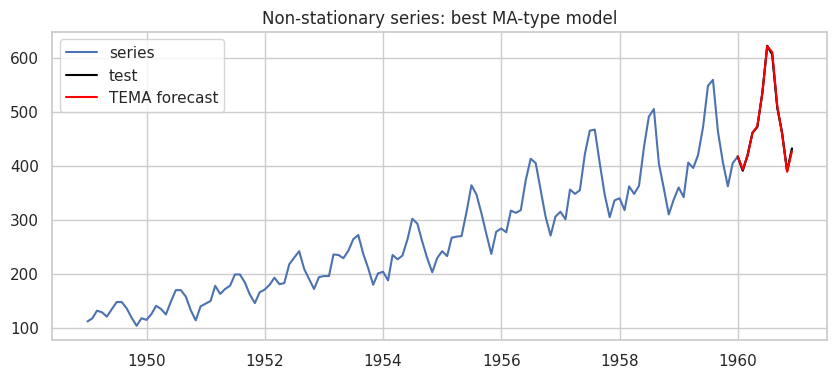

In [31]:
param_grid = range(2, 25)
models = ["MA", "EMA", "DEMA", "TEMA"]
best_nonstat = {}

for model_name in models:
    p, score = tune_and_evaluate_simple(ts_nonstat, model_name, param_grid, test_size=12)
    best_nonstat[model_name] = (p, score)
    print(f"Non-stationary | {model_name}: best_param={p}, best_RMSE={score}")

# фильтруем только те модели, где параметр подобран
valid_nonstat = {m: v for m, v in best_nonstat.items() if v[0] is not None}
print("Valid models for non-stationary series:", valid_nonstat)

best_model_nonstat = min(valid_nonstat.items(), key=lambda x: x[1][1])
print("Best model for non-stationary series:", best_model_nonstat)

best_name, (best_p, _) = best_model_nonstat

# строим прогноз лучшей модели на последнем хвосте
_, test_ns = train_test_split_ts(ts_nonstat, test_size=12)

if best_name == "MA":
    fitted_ns = ma(ts_nonstat, best_p)
elif best_name == "EMA":
    fitted_ns = ema(ts_nonstat, best_p)
elif best_name == "DEMA":
    fitted_ns = dema(ts_nonstat, best_p)
else:
    fitted_ns = tema(ts_nonstat, best_p)

forecast_ns = fitted_ns.iloc[-12:]

plt.plot(ts_nonstat.index, ts_nonstat, label="series")
plt.plot(test_ns.index, test_ns, label="test", color="black")
plt.plot(forecast_ns.index, forecast_ns, label=f"{best_name} forecast", color="red")
plt.legend()
plt.title("Non-stationary series: best MA-type model")
plt.show()




Эксперименты для стационарного ряда

In [32]:
best_stat = {}
for model_name in models:
    p, score = tune_and_evaluate_simple(ts_stat, model_name, param_grid, test_size=30)
    best_stat[model_name] = (p, score)
    print(f"Stationary | {model_name}: best_param={p}, best_RMSE={score}")

valid_stat = {m: v for m, v in best_stat.items() if v[0] is not None}
print("Valid models for stationary series:", valid_stat)

best_model_stat = min(valid_stat.items(), key=lambda x: x[1][1])
print("Best model for stationary series:", best_model_stat)


Stationary | MA: best_param=2, best_RMSE=6.967783004657938
Stationary | EMA: best_param=2, best_RMSE=3.8265070466649975
Stationary | DEMA: best_param=2, best_RMSE=1.8114753154712555
Stationary | TEMA: best_param=2, best_RMSE=0.8716934637653861
Valid models for stationary series: {'MA': (2, np.float64(6.967783004657938)), 'EMA': (2, np.float64(3.8265070466649975)), 'DEMA': (2, np.float64(1.8114753154712555)), 'TEMA': (2, np.float64(0.8716934637653861))}
Best model for stationary series: ('TEMA', (2, np.float64(0.8716934637653861)))


Выводы

В работе рассмотрены два ряда:

нестационарный — международные авиапассажиры;

стационарный — первые разности ежедневных женских рождений в Калифорнии.

Для каждого ряда протестированы модели MA, EMA, DEMA, TEMA с подбором параметра p по RMSE на последних точках ряда.

Нестационарный ряд (авиапассажиры)
Результаты:

MA, p = 2, RMSE ≈ 26.58

EMA, p = 2, RMSE ≈ 20.65

DEMA, p = 2, RMSE ≈ 6.71

TEMA, p = 2, RMSE ≈ 2.58

Лучшей оказалась модель TEMA(p = 2) с минимальным RMSE ≈ 2.58. Тройное экспоненциальное сглаживание лучше всего учитывает тренд и плавные изменения уровня нестационарного ряда, тогда как простое MA и однослойные EMA/DEMA дают заметно более высокую ошибку.

Стационарный ряд (разности рождений)

Результаты:

MA, p = 2, RMSE ≈ 6.97

EMA, p = 2, RMSE ≈ 3.83

DEMA, p = 2, RMSE ≈ 1.81

TEMA, p = 2, RMSE ≈ 0.87

И здесь наименьший RMSE показала модель TEMA(p = 2) с RMSE ≈ 0.87. Более сложная конструкция сглаживания даёт более точный прогноз, чем MA/EMA/DEMA, даже на стационарном ряде.

Итог

Для нестационарного ряда оптимальной моделью стала TEMA(p = 2) с RMSE ≈ 2.58.

Для стационарного ряда также оптимальной оказалась TEMA(p = 2) с RMSE ≈ 0.87.

Во всех проведённых экспериментах TEMA дала минимальную ошибку прогноза, поэтому её можно считать лучшей моделью среди рассмотренных MA‑подобных подходов для обоих рядов.
